# Open DAMIR, Assurance Maladie Reimbursement Analysis
## France, 2025 (January · June · December)

**Data source:** [Open Damir : base complète sur les dépenses d'assurance maladie - 2009 à 2025](https://www.assurance-maladie.ameli.fr/etudes-et-donnees/open-damir-depenses-sante-interregimes)  
**Codebook:** [Descriptif des variables Open DAMIR, base complète](https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fwww.assurance-maladie.ameli.fr%2Fsites%2Fdefault%2Ffiles%2F2024_descriptif-variables_open-damir-base-complete.xlsx&wdOrigin=BROWSELINK)  
**Coverage:** All reimbursement regimes, France entière  
**Tool:** DuckDB (SQL queries on raw CSV files, no data loading into memory)

### Research questions
How is Assurance Maladie (AM) spending distributed across care settings?  
What types of acts drive expenditure within soins de ville?  
How does spending vary across age groups?

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')

In [2]:
# Load PRS_NAT labels from codebook
from openpyxl import load_workbook

wb = load_workbook('C:/Users/Student/Downloads/Coding/Officials/2024_descriptif-variables_open-damir-base-complete.xlsx', read_only=True)
ws = wb['MOD OPEN DAMIR']

prs_nat_labels = {}
capture = False
for row in ws.iter_rows(values_only=True):
    if row[0] == 'PRS_NAT':
        capture = True
        continue
    if capture:
        if row[0] is None:
            continue
        # Stop when we hit the next variable section
        if isinstance(row[0], str) and row[0] != 'PRS_NAT':
            break
        if isinstance(row[0], int):
            prs_nat_labels[row[0]] = row[1]

In [3]:
FILES = [
    'C:/Users/Student/Downloads/Coding/Officials/A202501.csv',
    'C:/Users/Student/Downloads/Coding/Officials/A202506.csv',
    'C:/Users/Student/Downloads/Coding/Officials/A202512.csv'
]

In [4]:
counts = duckdb.query(f"""
    SELECT FLX_ANN_MOI, COUNT(*) AS n_rows
    FROM read_csv_auto({FILES})
    GROUP BY FLX_ANN_MOI
    ORDER BY FLX_ANN_MOI
""").df()

print(counts)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   FLX_ANN_MOI    n_rows
0       202501  36640259
1       202506  34412402
2       202512  35667937


## 1. Overall Reimbursement Volume
Total amount reimbursed by Assurance Maladie (`FLT_REM_MNT`) across all three months.

In [5]:
total = duckdb.query(f"""
    SELECT 
        FLX_ANN_MOI AS month,
        SUM(FLT_REM_MNT) AS total_reimbursed
    FROM read_csv_auto({FILES})
    GROUP BY FLX_ANN_MOI
    ORDER BY FLX_ANN_MOI
""").df()

print(total)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    month  total_reimbursed
0  202501 13,342,058,546.11
1  202506 14,008,474,127.66
2  202512 14,962,327,379.15


## 2. Reimbursement by Care Setting

Distribution of AM spending across care envelopes (`CPT_ENV_TYP`). 
Code 9 (valeur inconnue) is excluded from visualisations but retained in summary tables.

In [6]:
by_setting = duckdb.query(f"""
    SELECT
        FLX_ANN_MOI AS month,
        CPT_ENV_TYP AS care_setting,
        SUM(FLT_REM_MNT) AS total_reimbursed
    FROM read_csv_auto({FILES})
    GROUP BY FLX_ANN_MOI, CPT_ENV_TYP
    ORDER BY FLX_ANN_MOI, CPT_ENV_TYP
""").df()

print(by_setting)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     month  care_setting  total_reimbursed
0   202501             0      1,361,094.21
1   202501             1  9,235,273,227.90
2   202501             2  1,986,118,828.90
3   202501             3  1,515,456,127.15
4   202501             4      5,600,986.20
5   202501             5      3,647,567.15
6   202501             7         -4,546.30
7   202501             8         21,795.27
8   202501             9    594,583,465.67
9   202506             0      6,816,727.18
10  202506             1  9,658,811,461.69
11  202506             2  2,137,480,947.62
12  202506             3  1,589,629,436.18
13  202506             4      1,849,280.73
14  202506             5      4,905,977.88
15  202506             7         -3,420.50
16  202506             8         34,854.73
17  202506             9    608,948,862.19
18  202512             0     27,186,337.97
19  202512             1 10,488,527,425.35
20  202512             2  2,176,236,464.20
21  202512             3  1,607,931,206.61
22  202512 

#### Valeur inconnue: Act Type Breakdown
Investigating which act types (`PRS_NAT`) drive the 1.8B€ classified as valeur inconnue (`CPT_ENV_TYP = 9`).

In [7]:
code9_acts = duckdb.query(f"""
    SELECT PRS_NAT, SUM(FLT_REM_MNT) AS total_reimbursed
    FROM read_csv_auto({FILES})
    WHERE CPT_ENV_TYP = 9
    GROUP BY PRS_NAT
    ORDER BY total_reimbursed DESC
    LIMIT 20
""").df()

code9_acts['label'] = code9_acts['PRS_NAT'].map(prs_nat_labels)
print(code9_acts[['PRS_NAT', 'label', 'total_reimbursed']].to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    PRS_NAT                                                            label  total_reimbursed
0      2111                      FRAIS D HEBERGEMENT ET ENVIRONNEMENT EN GHS    147,229,911.21
1      3317                                    PHARMACIE HOSPITALIERE A 100%    122,449,763.81
2      3311                                                   PHARMACIE 100%     83,922,258.72
3      4214                                                            TAXIS     66,304,943.09
4      1352                  ACTES TECHNIQUES MEDICAUX  (hors IMAGERIE) CCAM     63,570,153.05
5      3511  APPAREILS D  ASSISTANCE RESPIRATOIRE,OXYGENOTHERAPIE A DOMICILE     57,101,332.78
6      3313                                                    PHARMACIE 65%     55,090,955.24
7      1103                                      AVIS PONCTUEL DE CONSULTANT     54,982,941.47
8      2110                                                 FRAIS SEJOUR SSR     53,981,411.97
9      3211                                       

#### Findings Breakdown

Code 9 (1.8B€) is dominated by hospital stay charges: frais d'hébergement en GHS (147M€) and frais de séjour SSR (53M€). The rest is a mix of pharmacy, transport, and paramedical acts where `CPT_ENV_TYP` was not transmitted, likely from smaller regimes.

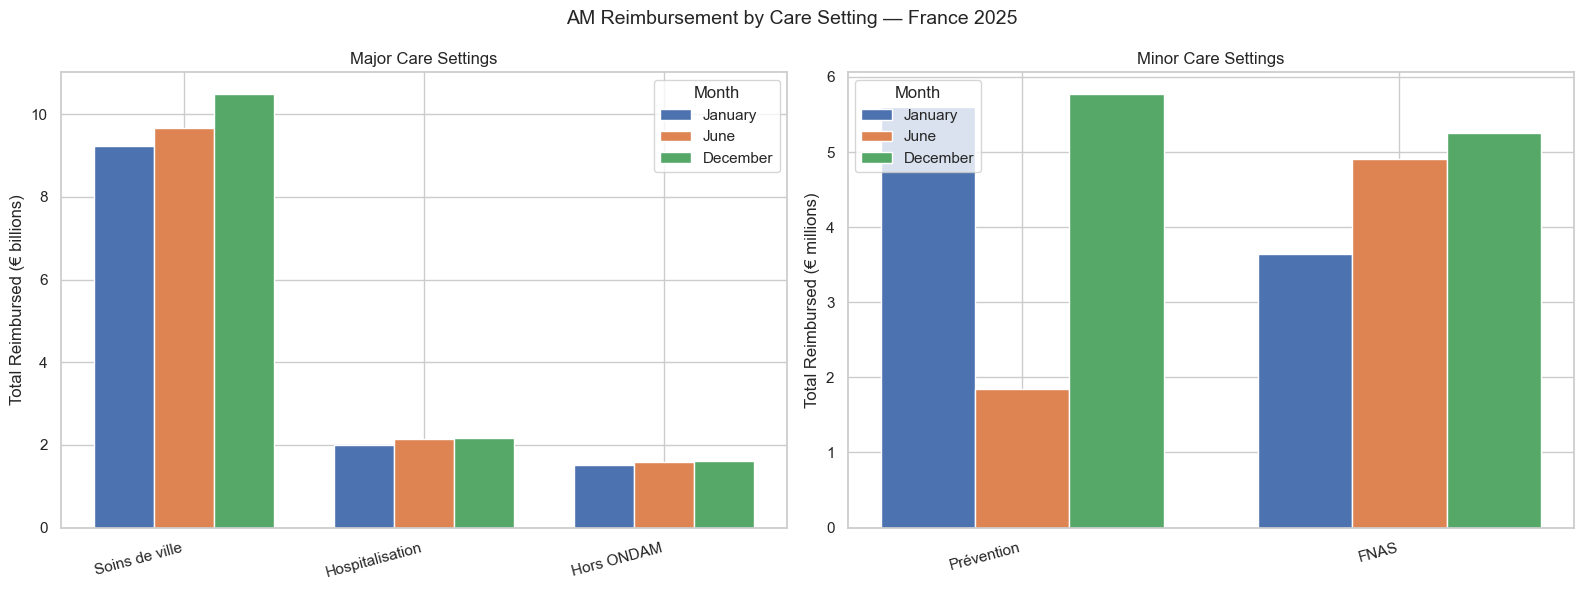

In [8]:
setting_labels = {
    1: 'Soins de ville',
    2: 'Hospitalisation',
    3: 'Hors ONDAM',
    4: 'Prévention',
    5: 'FNAS',
}

month_labels = {
    202501: 'January',
    202506: 'June',
    202512: 'December'
}

plot_data = by_setting[
    by_setting['care_setting'].isin(setting_labels.keys())
].copy()

plot_data['care_setting'] = plot_data['care_setting'].map(setting_labels)
plot_data['month'] = plot_data['month'].map(month_labels)
plot_data['total_reimbursed_bn'] = plot_data['total_reimbursed'] / 1e9
plot_data['total_reimbursed_mn'] = plot_data['total_reimbursed'] / 1e6

months = ['January', 'June', 'December']
major = ['Soins de ville', 'Hospitalisation', 'Hors ONDAM']
minor = ['Prévention', 'FNAS']
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i, month in enumerate(months):
    data = plot_data[plot_data['month'] == month].set_index('care_setting')
    ax1.bar([xi + i * width for xi in range(len(major))],
            data.reindex(major)['total_reimbursed_bn'],
            width=width, label=month)
    ax2.bar([xi + i * width for xi in range(len(minor))],
            data.reindex(minor)['total_reimbursed_mn'],
            width=width, label=month)

for ax, cats, title, ylabel in [
    (ax1, major, 'Major Care Settings', 'Total Reimbursed (€ billions)'),
    (ax2, minor, 'Minor Care Settings', 'Total Reimbursed (€ millions)')
]:
    ax.set_xticks([xi + width for xi in range(len(cats))])
    ax.set_xticklabels(cats, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Month')

plt.suptitle('AM Reimbursement by Care Setting — France 2025', fontsize=14)
plt.tight_layout()
plt.show()

### Findings: Care Setting

Soins de ville accounts for 69% of total AM spending, ranging from 9.2B€ in January to 10.5B€ in December. 

Hospitalisation remains stable across months at approximately 2B€, suggesting hospital reimbursements are less sensitive to seasonal variation than community-based care.

Prestations hors ONDAM reach 1.5B€ per month, driven by invalidity, maternity, and workplace accident compensation (categories outside the national health budget).

December shows the highest soins de ville expenditure across all three months, consistent with increased care-seeking at year end.

Minor categories (Prévention & FNAS) represent negligible amounts in absolute terms and are not analysed further in this notebook.

## 3. Soins de Ville: Expenditure by Act Type
Reimbursements within soins de ville (`CPT_ENV_TYP = 1`) broken down by nature de prestation (`PRS_NAT`).  
Top 50 act codes by reimbursement value, grouped into 12 categories. Coverage: 89.8% of total soins de ville expenditure.

In [9]:
sdv_acts = duckdb.query(f"""
    SELECT
        PRS_NAT,
        SUM(FLT_REM_MNT) AS total_reimbursed
    FROM read_csv_auto({FILES})
    WHERE CPT_ENV_TYP = 1
    GROUP BY PRS_NAT
    ORDER BY total_reimbursed DESC
    LIMIT 50
""").df()

# Merge with query results
sdv_acts['label'] = sdv_acts['PRS_NAT'].map(prs_nat_labels).fillna('LABEL NON TROUVE')
sdv_acts['total_reimbursed_bn'] = sdv_acts['total_reimbursed'] / 1e9

print(sdv_acts[['PRS_NAT', 'label', 'total_reimbursed']].to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    PRS_NAT                                                                                    label  total_reimbursed
0      3313                                                                            PHARMACIE 65%  4,424,433,676.55
1      6111                                                                      IJ NORMALES -3 MOIS  1,771,443,666.88
2      3311                                                                           PHARMACIE 100%  1,717,652,862.59
3      1110                                                           CONSULTATION MEDECINE GENERALE  1,358,476,484.36
4      6112                                                                       IJ NORMALES +3MOIS  1,257,718,846.25
5      6115                                                                       IJ MAJOREES -3MOIS  1,224,662,443.23
6      1352                                          ACTES TECHNIQUES MEDICAUX  (hors IMAGERIE) CCAM  1,203,569,102.91
7      3111                                     

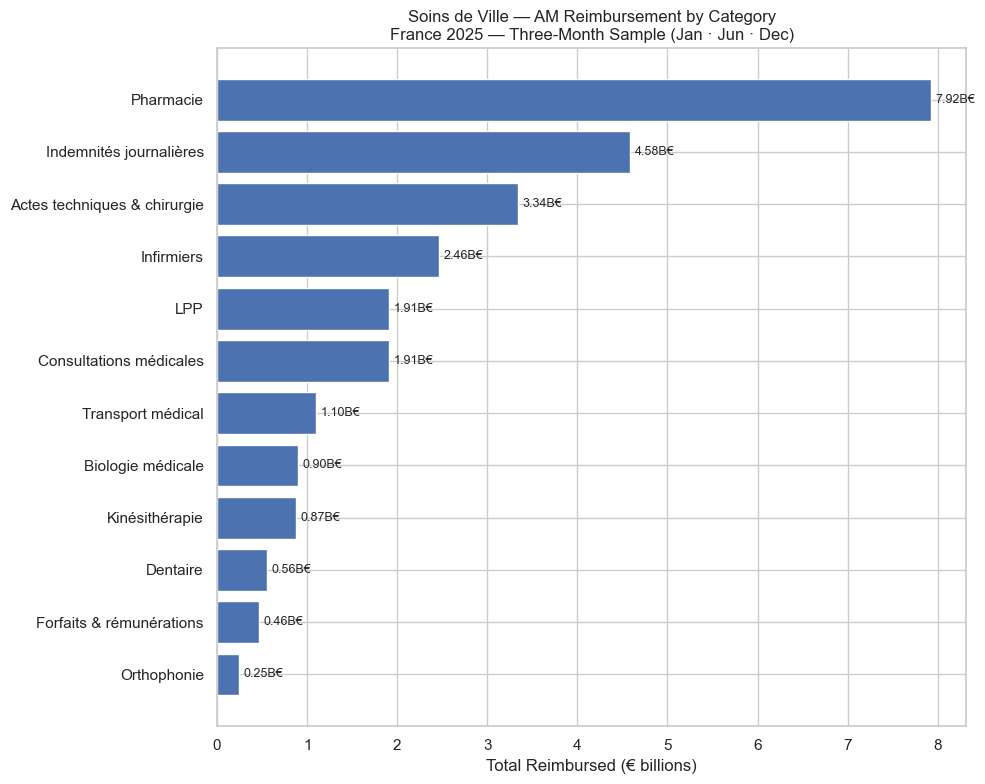

                             total_reimbursed_bn
category                                        
Pharmacie                                 7.92B€
Indemnités journalières                   4.58B€
Actes techniques & chirurgie              3.34B€
Infirmiers                                2.46B€
LPP                                       1.91B€
Consultations médicales                   1.91B€
Transport médical                         1.10B€
Biologie médicale                         0.90B€
Kinésithérapie                            0.87B€
Dentaire                                  0.56B€
Forfaits & rémunérations                  0.46B€
Orthophonie                               0.25B€
Valeur inconnue                           0.12B€


In [10]:
# Category mapping
category_map = {
    3311: 'Pharmacie', 3312: 'Pharmacie', 3313: 'Pharmacie',
    3316: 'Pharmacie', 3317: 'Pharmacie', 3366: 'Pharmacie', 3386: 'Pharmacie',
    6111: 'Indemnités journalières', 6112: 'Indemnités journalières',
    6115: 'Indemnités journalières', 6117: 'Indemnités journalières',
    6118: 'Indemnités journalières',
    1321: 'Actes techniques & chirurgie', 1323: 'Actes techniques & chirurgie',
    1324: 'Actes techniques & chirurgie', 1351: 'Actes techniques & chirurgie',
    1352: 'Actes techniques & chirurgie', 2351: 'Actes techniques & chirurgie',
    2352: 'Actes techniques & chirurgie',
    1103: 'Consultations médicales', 1110: 'Consultations médicales',
    1112: 'Consultations médicales', 1113: 'Consultations médicales',
    3106: 'Infirmiers', 3107: 'Infirmiers', 3108: 'Infirmiers',
    3111: 'Infirmiers', 3120: 'Infirmiers', 1842: 'Infirmiers', 1848: 'Infirmiers',
    3148: 'Kinésithérapie', 3152: 'Kinésithérapie',
    3157: 'Kinésithérapie', 3161: 'Kinésithérapie',
    3511: 'LPP', 3512: 'LPP', 3514: 'LPP',
    3515: 'LPP', 3522: 'LPP', 3545: 'LPP',
    4212: 'Transport médical', 4213: 'Transport médical',
    4214: 'Transport médical',
    4245: 'Valeur inconnue',
    3211: 'Biologie médicale',
    3132: 'Orthophonie',
    1424: 'Dentaire', 1451: 'Dentaire', 1453: 'Dentaire',
    1173: 'Forfaits & rémunérations',
}

# Merge labels and categories
sdv_acts['label'] = sdv_acts['PRS_NAT'].map(prs_nat_labels).fillna('Valeur inconnue')
sdv_acts['category'] = sdv_acts['PRS_NAT'].map(category_map).fillna('Autre')

# Summary by category
by_category = (
    sdv_acts
    .groupby('category')[['total_reimbursed']]
    .sum()
    .sort_values('total_reimbursed', ascending=False)
)
by_category['total_reimbursed_bn'] = by_category['total_reimbursed'] / 1e9

# Visualise
plot_sdv = by_category[['total_reimbursed_bn']].copy()
plot_sdv = plot_sdv[plot_sdv.index != 'Valeur inconnue']
plot_sdv = plot_sdv.sort_values('total_reimbursed_bn', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_sdv.index, plot_sdv['total_reimbursed_bn'])
ax.set_xlabel('Total Reimbursed (€ billions)')
ax.set_title('Soins de Ville — AM Reimbursement by Category\nFrance 2025 — Three-Month Sample (Jan · Jun · Dec)')

for bar, val in zip(bars, plot_sdv['total_reimbursed_bn']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}B€', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print after chart so string conversion doesn't break chart
by_category['total_reimbursed_bn'] = by_category['total_reimbursed_bn'].map('{:.2f}B€'.format)
print(by_category[['total_reimbursed_bn']].to_string())

## 4. Reimbursement by Age Group
Distribution of AM spending across age brackets (`AGE_BEN_SNDS`).  
Age is calculated at time of care. Bracket 99 (unknown age) is excluded from visualisations.

In [11]:
by_age = duckdb.query(f"""
    SELECT
        AGE_BEN_SNDS AS age_group,
        SUM(FLT_REM_MNT) AS total_reimbursed
    FROM read_csv_auto({FILES})
    GROUP BY AGE_BEN_SNDS
    ORDER BY AGE_BEN_SNDS
""").df()

age_labels = {
    0: '0-19',
    20: '20-29',
    30: '30-39',
    40: '40-49',
    50: '50-59',
    60: '60-69',
    70: '70-79',
    80: '80+',
    99: 'Inconnu'
}

by_age['label'] = by_age['age_group'].map(age_labels)
by_age['total_reimbursed_bn'] = by_age['total_reimbursed'] / 1e9

print(by_age[['label', 'total_reimbursed_bn']].to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     label  total_reimbursed_bn
0     0-19                 2.57
1    20-29                 2.33
2    30-39                 3.89
3    40-49                 4.30
4    50-59                 6.98
5    60-69                 7.88
6    70-79                 7.55
7      80+                 6.27
8  Inconnu                 0.54


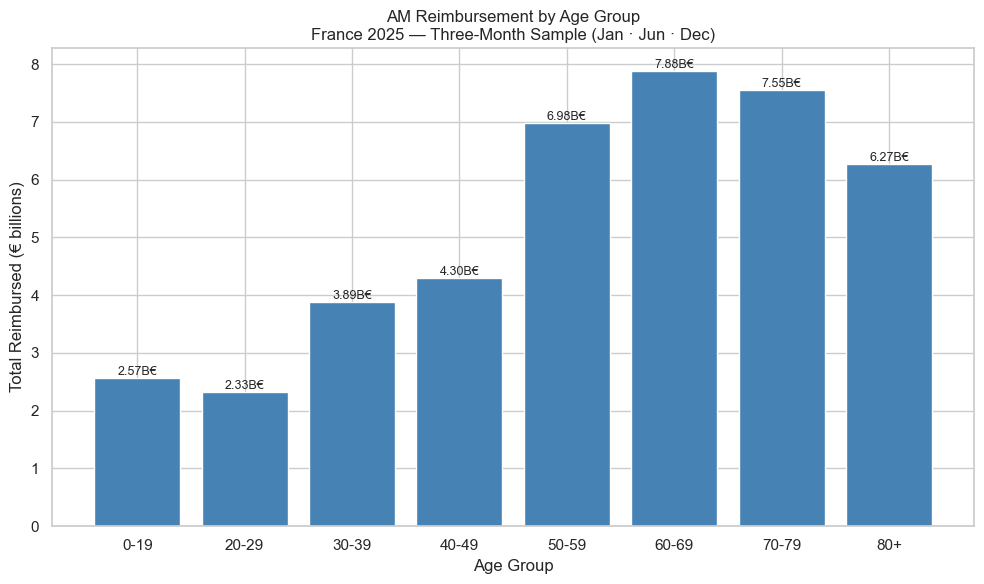

In [12]:
plot_age = by_age[by_age['label'] != 'Inconnu'].copy()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(plot_age['label'], plot_age['total_reimbursed_bn'], color='steelblue')

ax.set_xlabel('Age Group')
ax.set_ylabel('Total Reimbursed (€ billions)')
ax.set_title('AM Reimbursement by Age Group\nFrance 2025 — Three-Month Sample (Jan · Jun · Dec)')

for bar, val in zip(bars, plot_age['total_reimbursed_bn']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}B€', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusions

This analysis covers approximately 106.7 million reimbursement rows across three months (January, June, December 2025), representing 42.3B€ in total AM reimbursements.

### Key findings

- **Soins de ville accounts for 29.3B€** (69% of total reimbursements). The remainder is split between hospitalisation, prestations hors ONDAM, and other categories (detailed in section 2).

- **Pharmacy is the largest expenditure category within soins de ville** at 7.92B€ across the three months, exceeding surgical acts (3.34B€) and medical consultations (1.91B€) combined. Standard prescription drugs reimbursed at 65% account for the largest share (4.42B€).

- **Indemnités journalières (sick pay) represent 4.58B€**, which is the second largest category within soins de ville.

- **AM reimbursement increases with age**, peaking at 60-69 (7.88B€) before declining for 80+ (6.27B€). This decline likely reflects the fact that the 80+ population is  smaller in size, and that older patients shift toward institutionalised care 
  (hospitalisation, EHPAD) which is captured differently in the data.

- **December shows higher expenditure** across care settings compared to January and 
  June, most notably in soins de ville (+14% vs January).

### Limitations

- Three non-consecutive months — findings reflect structure and distribution  across the year, not annualised totals.
- Age group totals reflect population size as much as individual consumption. The 60-69 group may simply be larger than 80+, not necessarily more expensive  per person.
- Approximately 1.8B€ classified under code 9 (valeur inconnue) across care 
  settings remains uninterpretable.
